In [1]:
#!pip install pyodbc

In [16]:
import pyodbc
import pandas as pd
import csv

# Konfiguracja połączenia zapisana w formie słownika
connection_config = {
    'server': 'analityk.wwsi.edu.pl,50221',
    'database': 'synop',
    'user': 'student',
    'password': 'ciekawski',
    'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'driver': '{ODBC Driver 18 for SQL Server}',  # To jest nazwa sterownika ODBC
    'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
}

# Tworzenie łańcucha połączenia z konfiguracji
connection_string = (
    f"DRIVER={connection_config['driver']};"
    f"SERVER={connection_config['server']};"
    f"DATABASE={connection_config['database']};"
    f"UID={connection_config['user']};"
    f"PWD={connection_config['password']};"
    f"Encrypt={connection_config['encrypt']};"
    f"TrustServerCertificate={connection_config['trust_server_certificate']};"
)

try:
    # Nawiązanie połączenia
    conn = pyodbc.connect(connection_string)

    # Wykonanie operacji na bazie danych
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'")
    rows = cursor.fetchall()
    # for row in rows:
    # Zapisz wyniki do pliku CSV

    with open('DaneModelTMP_.csv', 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow([i[0] for i in cursor.description])  # Nagłówki kolumn
        csv_writer.writerows(rows)  # Dane

except pyodbc.Error as ex:
    print(f"Błąd połączenia: {ex}")

finally:
    if 'conn' in locals():
        conn.close()

In [20]:
import pyodbc
import pandas as pd
import csv

# Konfiguracja połączenia zapisana w formie słownika
connection_config = {
    'server': 'analityk.wwsi.edu.pl,50221',
    'database': 'synop',
    'user': 'student',
    'password': 'ciekawski',
    'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'driver': '{ODBC Driver 18 for SQL Server}',  # To jest nazwa sterownika ODBC
    'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
}

# Tworzenie łańcucha połączenia z konfiguracji
connection_string = (
    f"DRIVER={connection_config['driver']};"
    f"SERVER={connection_config['server']};"
    f"DATABASE={connection_config['database']};"
    f"UID={connection_config['user']};"
    f"PWD={connection_config['password']};"
    f"Encrypt={connection_config['encrypt']};"
    f"TrustServerCertificate={connection_config['trust_server_certificate']};"
)

# Nawiązanie połączenia
conn = pyodbc.connect(connection_string)

# Wykonanie operacji na bazie danych
#cursor = conn.cursor()
#    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'")
#    rows = cursor.fetchall()
    # for row in rows:
query = "SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'"
df = pd.read_sql(query, conn)
    # Zapisz wyniki do pliku CSV
print(df.head())
conn.close()

                 czas        data  Pora  miesiac  Widz3  Widz6    Zachm3  \
0 2013-08-06 04:00:00  2013-08-06     1        8  30000  30000  0.000000   
1 2013-08-06 08:00:00  2013-08-06     2        8  20000  23333  1.000000   
2 2013-08-06 12:00:00  2013-08-06     3        8  30000  26666  2.333333   
3 2013-08-06 16:00:00  2013-08-06     4        8  30000  30000  2.666666   
4 2013-08-06 20:00:00  2013-08-06     5        8  30000  30000  2.000000   

     Zachm6   ZachmN3   ZachmN6  ... OpadM_E OpadM_N OpadM_S Przelotny_W  \
0  0.000000  0.000000  0.000000  ...       0       0       0           0   
1  0.500000  0.000000  0.000000  ...       0       0       0           0   
2  1.833333  1.333333  0.833333  ...       0       0       0           0   
3  2.666666  1.666666  1.666666  ...       0       0       0           0   
4  2.166666  1.000000  1.166666  ...       0       0       0           0   

   Przelotny_E  Przelotny_N  Przelotny_S  Pred3  Pred6   id  
0            0          

In [21]:
# import warnings
# import pandas as pd
# from io import StringIO
# warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
# df = pd.read_csv('DaneModelTMP.csv', delimiter=',')

In [22]:
df

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id
0,2013-08-06 04:00:00,2013-08-06,1,8,30000,30000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,169
1,2013-08-06 08:00:00,2013-08-06,2,8,20000,23333,1.000000,0.500000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,170
2,2013-08-06 12:00:00,2013-08-06,3,8,30000,26666,2.333333,1.833333,1.333333,0.833333,...,0,0,0,0,0,0,0,-1,0,171
3,2013-08-06 16:00:00,2013-08-06,4,8,30000,30000,2.666666,2.666666,1.666666,1.666666,...,0,0,0,0,0,0,0,-1,0,172
4,2013-08-06 20:00:00,2013-08-06,5,8,30000,30000,2.000000,2.166666,1.000000,1.166666,...,0,0,0,0,0,0,0,-1,0,173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,2022-12-21 23:00:00,2022-12-21,5,12,2266,3216,8.000000,8.000000,8.000000,7.666666,...,0,0,0,1,0,0,0,-1,2,180009
152766,2022-12-22 00:00:00,2022-12-22,0,12,2533,2883,8.000000,8.000000,7.666666,7.666666,...,0,0,0,0,0,0,0,-1,2,180010
152767,2022-12-22 01:00:00,2022-12-22,0,12,2800,2750,8.000000,8.000000,7.333333,7.666666,...,0,0,0,0,0,1,0,-1,2,180011
152768,2022-12-22 02:00:00,2022-12-22,0,12,2500,2383,8.000000,8.000000,7.000000,7.500000,...,0,0,0,0,0,1,0,-1,2,180012


In [114]:
#!pip install sqlalchemy

In [26]:
df.shape

(152770, 62)

In [25]:
df.Widz3

0         30000
1         20000
2         30000
3         30000
4         30000
          ...  
152765     2266
152766     2533
152767     2800
152768     2500
152769     1900
Name: Widz3, Length: 152770, dtype: int64

In [24]:
df.columns.values

array(['czas', 'data', 'Pora', 'miesiac', 'Widz3', 'Widz6', 'Zachm3',
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S',
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6',
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy',
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12',
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6',
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E',
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S',
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W',
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N',
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N',
       'Przelotny_S', 'Pred3', 'Pred6', 'id'], dtype=object)

In [118]:
import pandas as pd

# Usuń wiersze, gdzie przynajmniej jedna kolumna ma wartość -9
df = df[(df != -9).all(1)]

# Wyświetl wynik
print(df)

                       czas        data  Pora  miesiac  Widz3  Widz6  \
168     2013-08-06 04:00:00  2013-08-06     1        8  30000  30000   
169     2013-08-06 08:00:00  2013-08-06     2        8  20000  23333   
170     2013-08-06 12:00:00  2013-08-06     3        8  30000  26666   
171     2013-08-06 16:00:00  2013-08-06     4        8  30000  30000   
172     2013-08-06 20:00:00  2013-08-06     5        8  30000  30000   
...                     ...         ...   ...      ...    ...    ...   
173181  2022-12-21 23:00:00  2022-12-21     5       12   2266   3216   
173182  2022-12-22 00:00:00  2022-12-22     0       12   2533   2883   
173183  2022-12-22 01:00:00  2022-12-22     0       12   2800   2750   
173184  2022-12-22 02:00:00  2022-12-22     0       12   2500   2383   
173185  2022-12-22 03:00:00  2022-12-22     0       12   1900   2216   

          Zachm3    Zachm6   ZachmN3   ZachmN6  ...  OpadM_E  OpadM_N OpadM_S  \
168     0.000000  0.000000  0.000000  0.000000  ...   

In [119]:
df.drop(['Pred3'], axis=1, inplace=True)

/home/miniyoda87/.local/lib/python3.10/site-packages/pandas/core/frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [120]:
print(df)

                       czas        data  Pora  miesiac  Widz3  Widz6  \
168     2013-08-06 04:00:00  2013-08-06     1        8  30000  30000   
169     2013-08-06 08:00:00  2013-08-06     2        8  20000  23333   
170     2013-08-06 12:00:00  2013-08-06     3        8  30000  26666   
171     2013-08-06 16:00:00  2013-08-06     4        8  30000  30000   
172     2013-08-06 20:00:00  2013-08-06     5        8  30000  30000   
...                     ...         ...   ...      ...    ...    ...   
173181  2022-12-21 23:00:00  2022-12-21     5       12   2266   3216   
173182  2022-12-22 00:00:00  2022-12-22     0       12   2533   2883   
173183  2022-12-22 01:00:00  2022-12-22     0       12   2800   2750   
173184  2022-12-22 02:00:00  2022-12-22     0       12   2500   2383   
173185  2022-12-22 03:00:00  2022-12-22     0       12   1900   2216   

          Zachm3    Zachm6   ZachmN3   ZachmN6  ...  OpadM_W  OpadM_E OpadM_N  \
168     0.000000  0.000000  0.000000  0.000000  ...   

In [121]:
X

,Pora,Zachm3,Zachm6,ZachmN3,ZachmN6,Wiatr_N,Wiatr_E,Wiatr_S,Wiatr_W,DeltaTemp3,...,Snieg_N,Snieg_S,OpadM_W,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S
168,1,0.000000,0.000000,0.000000,0.000000,0.0000,2.9544,0.5209,0.0000,-0.2,...,0,0,0,0,0,0,0,0,0,0
169,2,1.000000,0.500000,0.000000,0.000000,0.0000,2.5981,1.5000,0.0000,6.2,...,0,0,0,0,0,0,0,0,0,0
170,3,2.333333,1.833333,1.333333,0.833333,0.0000,1.9284,2.2981,0.0000,2.3,...,0,0,0,0,0,0,0,0,0,0
171,4,2.666666,2.666666,1.666666,1.666666,0.0000,1.2856,1.5321,0.0000,-1.1,...,0,0,0,0,0,0,0,0,0,0
172,5,2.000000,2.166666,1.000000,1.166666,0.0000,2.5981,1.5000,0.0000,-4.3,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173181,5,8.000000,8.000000,8.000000,7.666666,0.0000,0.0000,1.0000,0.0000,0.0,...,0,3,0,0,0,0,1,0,0,0
173182,0,8.000000,8.000000,7.666666,7.666666,0.0000,0.3420,0.9397,0.0000,0.0,...,0,3,0,0,0,0,0,0,0,0
173183,0,8.000000,8.000000,7.333333,7.666666,0.0000,0.3473,1.9696,0.0000,0.1,...,0,3,0,0,0,0,0,0,1,0
173184,0,8.000000,8.000000,7.000000,7.500000,1.8794,0.6840,0.0000,0.0000,0.1,...,0,3,0,0,0,0,0,0,1,0


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załadowanie zbioru danych
list_col = list(df.columns.values)

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizuj model k-NN z 3 sąsiadami
knn = KNeighborsClassifier(n_neighbors=20)

# Trenuj model na danych treningowych
knn.fit(X_train, y_train)

# Przewiduj klasy na danych testowych
y_pred = knn.predict(X_test)

# Oblicz dokładność modelu
accuracy = accuracy_score(y_test, y_pred)
print("Dokładność modelu: {:.2f}".format(accuracy))

ValueError: could not convert string to float: ',0.00'

In [122]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załadowanie zbioru danych
list_col = list(df.columns.values)

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizuj model k-NN z 3 sąsiadami
knn = KNeighborsClassifier(n_neighbors=20)

# Trenuj model na danych treningowych
knn.fit(X_train, y_train)

# Przewiduj klasy na danych testowych
y_pred = knn.predict(X_test)

# Oblicz dokładność modelu
accuracy = accuracy_score(y_test, y_pred)
print("Dokładność modelu: {:.2f}".format(accuracy))


ValueError: could not convert string to float: 'S3.762'

In [65]:
import matplotlib.pyplot as plt
# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    print(f"Testujemy model z {n} sąsiadami")
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)


# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()

Testujemy model z 1 sąsiadami


ValueError: could not convert string to float: 'E0.000'

In [6]:
# import matplotlib.pyplot as plt

# # Indeksy wybranych cech (pierwsza i druga kolumna)
# feature1 = [0,  1,  3]
# feature2 = [0,  1,  3]

# # Indeksy klas (unikalne wartości w y)
# classes = list(set(y))

# # Kolor każdej klasy
# colors = ['b', 'g', 'r']

# # Tytuł wykresu
# plt.title("K-NN Classification")

# # Rysowanie punktów danych
# for c in classes:
#     plt.scatter(X_test[y_test == c, feature1], X_test[y_test == c, feature2], c=colors[c], label="Class " + str(c))

# # Rysowanie punktów predykcji
# plt.scatter(X_test[:, feature1], X_test[:, feature2], c='k', marker='x', label="Predictions")

# plt.xlabel('nr pomiaru')
# plt.ylabel('Predictions')

# plt.legend(loc='best')

# plt.show()


In [7]:
# import matplotlib.pyplot as plt
# # Tworzenie wykresu dla predykcji kolejnych danych
# X_new = df[['id', 'Widz3']]

# # Przewidywanie klas na nowych danych
# y_new = knn.predict(X_new)

# print("Predykcje na nowych danych:")
# for i in range(len(X_new)):
#     print(f"Dane: {X_new[i]}, Predykcja klasy: {y_new[i]}")

# # Wykres klas
# plt.figure()
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolor='k')
# plt.xlabel('nr pomiaru')
# plt.ylabel('Predykcja widzialności na następne trzy godziny')

# plt.show()

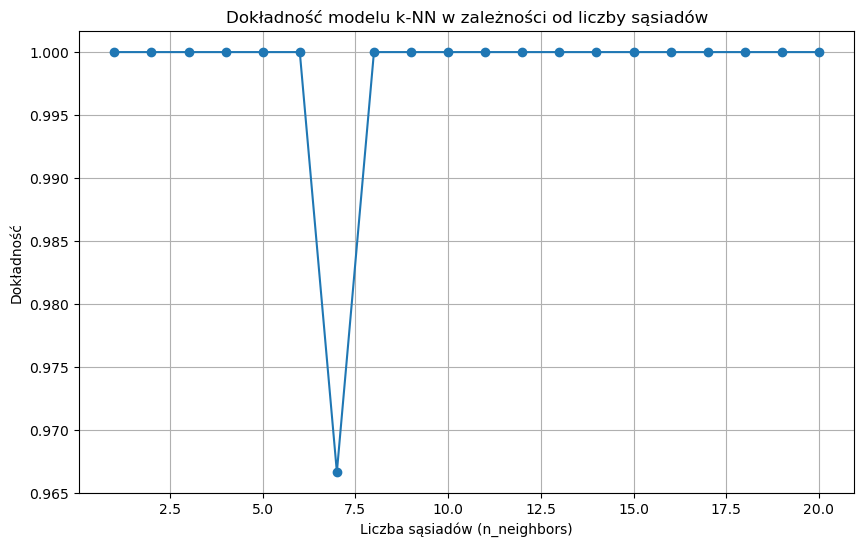

In [8]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załaduj przykładowy zbiór danych (Iris dataset)
iris = load_iris()
X, y = iris.data, iris.target

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()
